In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

# Control figure size
figsize=(14, 4)

from util import util
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV

# Generate synthetic data
data, name_map = util.generate_data(size=500, seed=42)
num_cols = [c for c in data.columns[:-1] if len(data[c].unique()) > 2]
cat_cols = [c for c in data.columns[:-1] if len(data[c].unique()) == 2]

# A Baseline Approach

## A Baseline Approach

**Our goal is _understading_ the process behind the data**

Of of many possible ways to do it consist in:

* Training an approximate model via Machine Learning
* Studying the model as a proxy for the real process

> **Basically, we use a ML model as an _analysis tool_**

**For this approach to work, we need the ML model to be _explainable_**

* A few model naturally enjoy this property (e.g. linear models, simple DTs)
* Explaining other models is not obvious (e.g. Neural Networks, large ensembles)

We will start with the simplest option: Logistic Regression

## Data Preprocessing

**We start with the usual data preprocessing**

We will treat all candidate correlates as inputs

In [ ]:
# Input-output separation
X, y = data[data.columns[:-1]].copy(), data[data.columns[-1]].copy()
#the reason why we do .copy is to avoid the SettingWithCopyWarning that pandas gives when you try to modify a slice of a DataFrame. By using .copy(), we create a new DataFrame that is independent of the original one, allowing us to safely modify it without affecting the original data or triggering warnings.

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Input standardization
#difference between standardization and normalization: Standardization (or Z-score normalization) transforms the data to have a mean of 0 and a standard deviation of 1, while normalization (or min-max scaling) scales the data to a fixed range, typically [0, 1]. Standardization is useful when the data has varying scales and you want to maintain the distribution of the data, while normalization is useful when you want to ensure that all features contribute equally to the model by scaling them to a common range.
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Even if we don't care about estimates, we need a _test/validation set_

* This will allow us to check the model for overfitting

We also need to standardize all numeric features

* This will make the model coefficients more easily interpretable

## On the Danger of Overfitting

**We plan to use our model as proxy for the true process**

...Which makes _overfitting is especially bad_

* Our results will stricly apply only to the model
* ...And they will be as general as the model

**We will use _L1 regularization_ on this purpose**

Scikit learn support L1 regularizers for Logistic Regression in the form:

$$
\mathop{\mathrm{argmin}_\theta} H(y, f(x, \theta)) + \frac{1}{C}\|\theta\|_1
$$

* We encourage the weights to be close to 0 (basically performing feature selection, i.e. identifying the most important features)
* ...And we attempt to sparsify the weights

## Training our "Proxy" Model

**We can calibrate the $C$ parameter via cross-validation**

We'll need the [SAGA solver](https://www.di.ens.fr/~fbach/Defazio_NIPS2014.pdf) to train our model with L1 regularization

In [ ]:
base_est = LogisticRegression(penalty='l1', solver='saga') #saga is a solver that supports L1 regularization, which encourages sparsity in the model coefficients. By using L1 regularization, we can perform feature selection by driving some coefficients to zero, effectively removing less important features from the model. This can help improve model interpretability and reduce overfitting by focusing on the most relevant features in the dataset.
param_grid={'C': 1. / np.linspace(1e-1, 1e4, 100)}
gscv = GridSearchCV(base_est, param_grid=param_grid, scoring='roc_auc')
gscv.fit(X_train, y_train)
lr, lr_params = gscv.best_estimator_, gscv.best_params_

**Then we can check the performance of the refitted estimator**

In [4]:
lr_score_cv, lr_score_test = gscv.best_score_, roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f'AUC score for C={lr_params["C"]:.2f}: {lr_score_cv:.2f} (cross-validation), {lr_score_test:.2f} (test)')

AUC score for C=10.00: 0.64 (cross-validation), 0.60 (test)


* We use the AUC score, since this is not a deterministic classification problem.
Because AUC measures the model's ranking/separation across all thresholds, while accuracy depends on a single chosen threshold and can be misleading (e.g., a model that perfectly orders positives above negatives but whose scores fall on the wrong side of 0.5 will have poor accuracy but AUC = 1). AUC is therefore more robust to threshold choice and class imbalance.
* There's no significant overfitting

## Coefficient Analysis

**Finally, we can analyze the model coefficients**

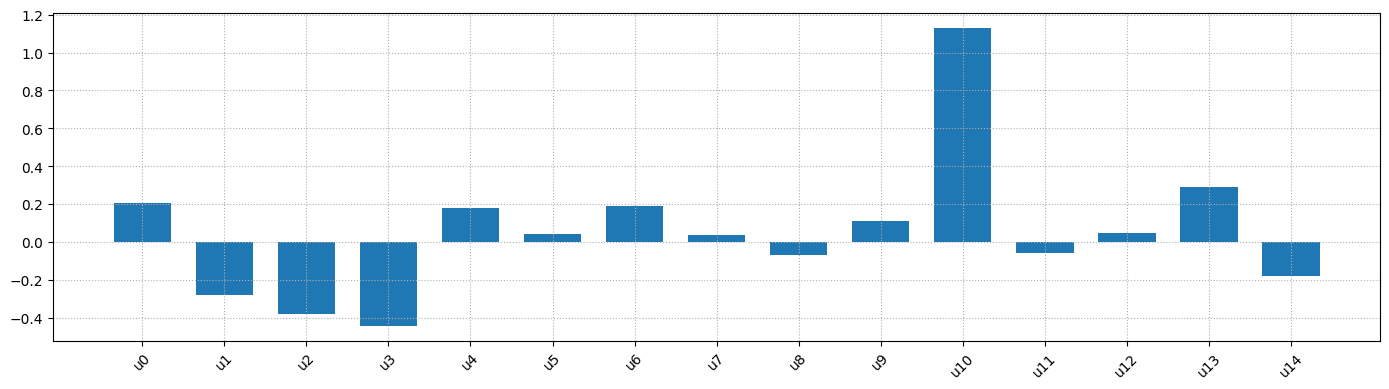

In [5]:
lr_coefs = pd.Series(index=X.columns, data=lr.coef_[0])
util.plot_bars(lr_coefs, figsize=figsize)

* Some variables seem to be more important than others
* The sign tells us how they are linked to the target

<div class=big>
<span class=small>This baseline approach has <i>many</i> issues</span><br>
Can you spot a few ones?
</div>

## Three Key Issues with our Baseline

**Issue 1: our model has _poor accuracy_**

* An AUC score of 0.6 is not much above random
* ...Hence, studying our model will say little about the data

**Issue 2: our model can only capture _linear correlations_**

* We can capture neither non-linear effects
* ...Nor interactions among the variables

**Issue 3: the coefficients are not sparse**

* The L1 terms needs both to sparsify and to prevent overfitting
* ...And it cannot do both things effectively
* Additionally: it's unclear what a good level of sparsification might be

<div class=big>
We'll now get to work to fix them
</div>